# Cold Diffusion: CIFAR-10 Re-implementation

Re-implementation of *Cold Diffusion: Inverting Arbitrary Image Transforms Without Noise* (Bansal et al., 2022) on CIFAR-10. Walks through the core experiments:

1. **Forward degradations** — visualizing inpainting, blur, and super-resolution as `D(x_0, t)` over `t = 0..T`.
2. **Reconstruction** — direct one-shot prediction vs. Algorithm 2 iterative sampling.
3. **Sampler comparison** — Algorithm 1 (naive) vs Algorithm 2 (paper §3.3).
4. **Metrics** — FID / SSIM / RMSE over the test set, mirroring Tables 1–3.
5. **Comparison across degradations** — train inpainting / super-resolution / blur and compare reconstructions.
6. **Cold generation** — unconditional samples via the §5.3 random-color-fill trick (optional, retrains a separate model).

Run order: top to bottom. Cells that train assume a CUDA GPU.

## Setup

In [ ]:
import sys, os, pathlib, subprocess

REPO_URL  = 'https://github.com/J0hns0n-Wang/CS4782_Final_Project.git'
REPO_NAME = 'CS4782_Final_Project'

def _find_root():
    here = pathlib.Path('.').resolve()
    for d in [here, *here.parents]:
        if (d / 'src' / '__init__.py').exists():
            return d
    for child in here.iterdir():
        if child.is_dir() and (child / 'src' / '__init__.py').exists():
            return child.resolve()
    return None

ROOT = _find_root()

# On Colab the kernel runs on a fresh remote VM with no project files.
# Clone from GitHub if we can't find src/.
if ROOT is None:
    on_colab = 'google.colab' in sys.modules or os.path.exists('/content')
    if on_colab:
        target = pathlib.Path('/content') / REPO_NAME
        if not target.exists():
            subprocess.check_call(['git', 'clone', '--depth', '1', REPO_URL, str(target)])
        ROOT = target
    else:
        raise RuntimeError(
            'Could not find src/__init__.py walking up from '
            f'{pathlib.Path(".").resolve()}. Run this notebook from inside '
            'the CS4782_Final_Project folder.'
        )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('project root:', ROOT)

# torchmetrics[image] / torch-fidelity is needed for FID. The base
# torchmetrics package without the image extras throws ModuleNotFoundError
# when FrechetInceptionDistance is constructed.
def _ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

_ensure('torchmetrics')
_ensure('torch-fidelity', 'torch_fidelity')

import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Device selection: prefer TPU (torch_xla is preinstalled on Colab TPU
# runtimes), then CUDA, then CPU.
#
# WARNING for TPU users: src/training/train.py uses vanilla PyTorch
# (no xm.mark_step / xm.optimizer_step / ParallelLoader). Tensors will
# live on the XLA device, but without those primitives the TPU is not
# being used efficiently -- expect TPU runs to be slower than a T4 GPU
# until the loop is rewritten with torch_xla. If you want speed on free
# Colab, switch the runtime to "T4 GPU" instead.
try:
    import torch_xla.core.xla_model as xm  # type: ignore
    DEVICE = xm.xla_device()
    print('device: TPU (xla) ->', DEVICE)
except ImportError:
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print('device:', DEVICE)

torch.manual_seed(0)

# Persistent checkpoint location. On Colab we mount Drive so checkpoints
# survive VM resets / runtime switches; locally we use the repo's results/
# folder. Every training cell writes to f'{CKPT_BASE}/<run_name>' and
# auto-detects existing checkpoints so you can resume eval in a fresh
# session without retraining.
CKPT_BASE = 'results/checkpoints'
if 'google.colab' in sys.modules:
    try:
        from google.colab import drive
        if not os.path.ismount('/content/drive'):
            drive.mount('/content/drive')
        CKPT_BASE = '/content/drive/MyDrive/cold_diffusion_ckpts'
    except Exception as e:
        print(f'WARNING: Drive mount failed ({e}); checkpoints will be on the '
              'ephemeral Colab VM and lost on disconnect')
os.makedirs(CKPT_BASE, exist_ok=True)
print('checkpoints ->', CKPT_BASE)

In [ ]:
from src.training.dataset import cifar10_loaders
from src.degradations import GaussianMaskInpainting, GaussianBlur, SuperResolution
from src.diffusion.cold import ColdDiffusion
from src.models.unet import UNet
from src.models.ema import EMA
from src.training.train import train

# Paper recipe (Appendix A.1, A.2): per-step batch 64, accumulate_every=2
# inside train() -> effective batch 128. Random horizontal flip is on by
# default in cifar10_loaders. lr 2e-5, EMA 0.995 every 10 grad steps,
# L1 loss -- all set as defaults in src/training/train.py.
train_loader, test_loader = cifar10_loaders(batch_size=64, num_workers=2)
x0_demo, _ = next(iter(test_loader))
x0_demo = x0_demo[:8].to(DEVICE)
print('demo batch:', x0_demo.shape, x0_demo.min().item(), x0_demo.max().item())


def load_ema_from(run_dir, model_factory, step=None, device=None):
    """Reload an EMA from a saved checkpoint dir.

    model_factory: zero-arg callable returning a fresh restoration network
                   (e.g. lambda: UNet(image_size=32)). Must match the
                   architecture that was trained.
    step: int step to load, or None for the latest checkpoint.
    """
    device = device or DEVICE
    run_dir = pathlib.Path(run_dir)
    ckpts = sorted(run_dir.glob('ckpt_*.pt'))
    if not ckpts:
        raise FileNotFoundError(f'no ckpt_*.pt in {run_dir}')
    path = (run_dir / f'ckpt_{step:06d}.pt') if step is not None else ckpts[-1]
    print(f'loading {path}')
    state = torch.load(path, map_location=device)
    base = model_factory()
    base.load_state_dict(state['model'])
    ema = EMA(base)
    ema.load_state_dict(state['ema'])
    ema.ema_model.to(device)
    return ema


def has_checkpoint(run_dir):
    p = pathlib.Path(run_dir)
    return p.exists() and any(p.glob('ckpt_*.pt'))

## 1. Forward degradations

`D(x_0, t)` for `t = 0, T/4, T/2, 3T/4, T` for each operator. This is the paper's Figure 1, top three rows.

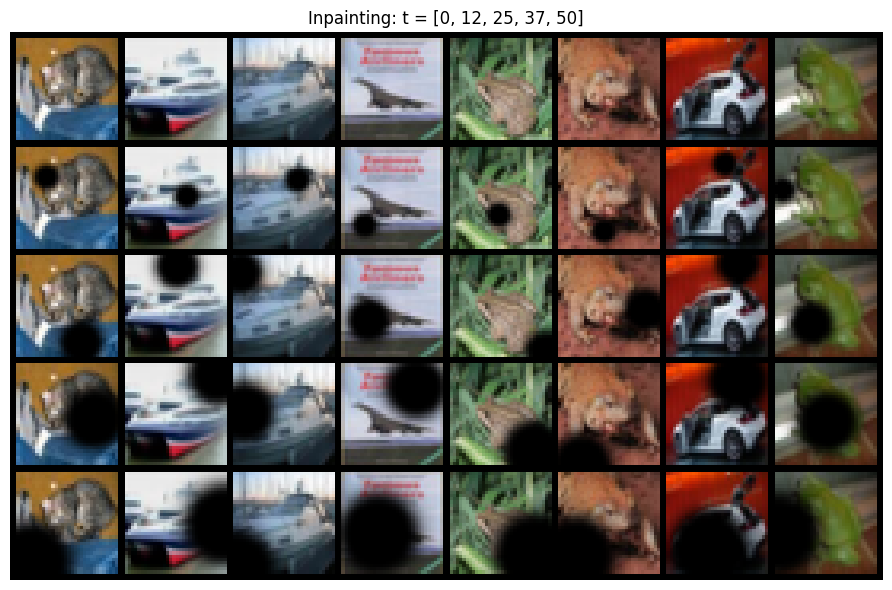

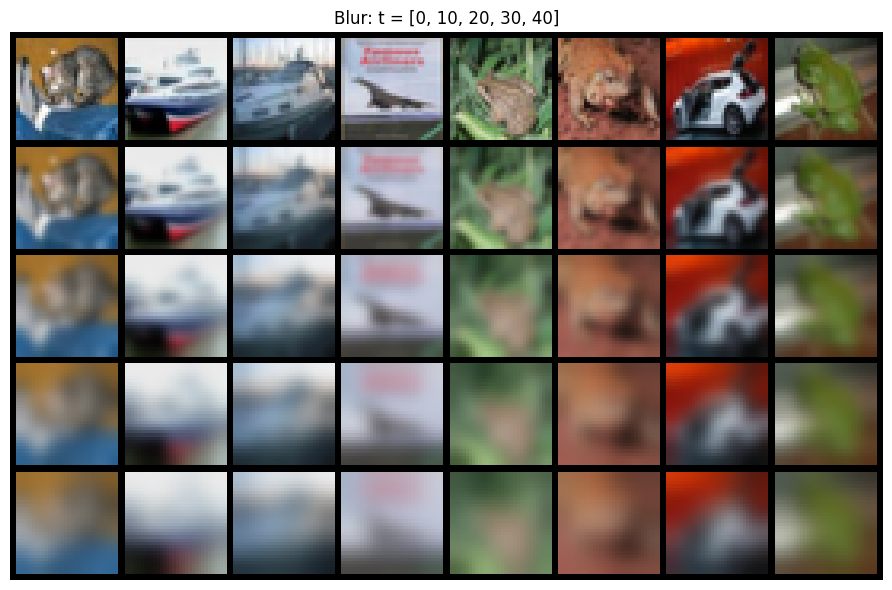

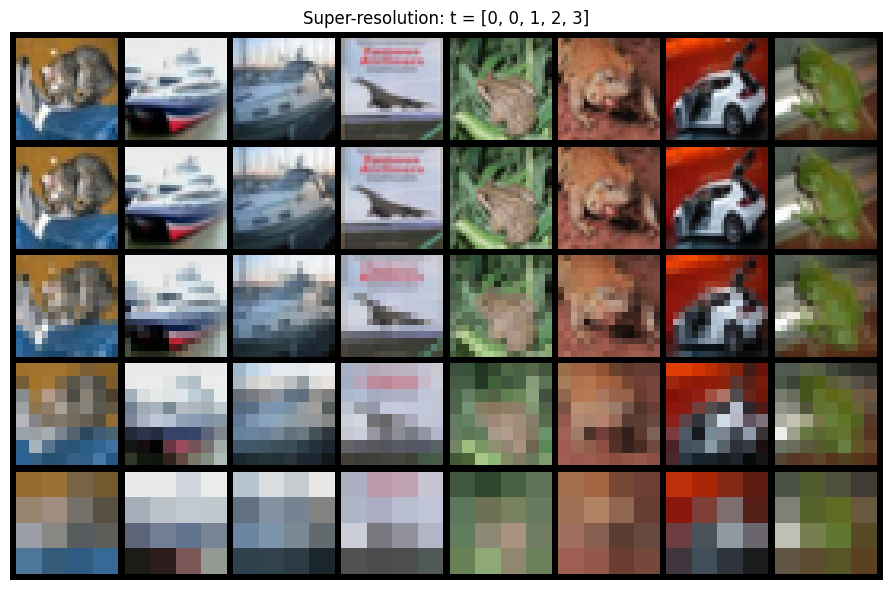

In [3]:
def show_degradation_progression(deg, T, x0, device, title=''):
    timesteps = [0, T // 4, T // 2, 3 * T // 4, T]
    rows = []
    deg = deg.to(device)
    for t_val in timesteps:
        t = torch.full((x0.shape[0],), t_val, device=device, dtype=torch.long)
        rows.append(deg(x0, t).clamp(0, 1).cpu())
    grid = make_grid(torch.cat(rows), nrow=x0.shape[0])
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(grid.permute(1, 2, 0))
    ax.set_title(f'{title}: t = {timesteps}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

show_degradation_progression(GaussianMaskInpainting(image_size=32, T=50), 50, x0_demo, DEVICE, 'Inpainting')
show_degradation_progression(GaussianBlur(kernel_size=11, T=40), 40, x0_demo, DEVICE, 'Blur')
show_degradation_progression(SuperResolution(image_size=32, T=3), 3, x0_demo, DEVICE, 'Super-resolution')

## 2. Train a Cold Diffusion model on the inpainting task

Paper recipe (Appendix A.2): 60k gradient steps at effective batch 128 (= per-step batch 64 × `accumulate_every=2`). On a Colab T4 this is roughly 3–4 hours. Set `TOTAL_STEPS` lower if you need to fit a single Colab session and just want to verify the pipeline.

Skip this cell if you've already saved a checkpoint.

In [ ]:
TOTAL_STEPS = 60_000   # paper recipe (Appendix A.2)
RUN_DIR = f'{CKPT_BASE}/inpainting_demo'

deg = GaussianMaskInpainting(image_size=32, T=50)

if has_checkpoint(RUN_DIR):
    print(f'Found existing inpainting checkpoint in {RUN_DIR}; loading instead of training.')
    ema = load_ema_from(RUN_DIR, lambda: UNet(image_size=32))
else:
    diffusion = ColdDiffusion(UNet(image_size=32), deg, T=50)
    ema = train(diffusion, train_loader, total_steps=TOTAL_STEPS,
                run_dir=RUN_DIR, device=DEVICE)

## 3. Reconstruction: direct vs Algorithm 2

In [ ]:
diff_eval = ColdDiffusion(ema.ema_model.to(DEVICE), deg.to(DEVICE), T=50).eval()
T = 50

with torch.no_grad():
    t_full = torch.full((x0_demo.shape[0],), T, device=DEVICE, dtype=torch.long)
    # Lock the per-image mask centers so xT and every D-call inside the
    # sampler share the same trajectory. Without this, Algorithm 2 sees
    # mismatched masks at every step and produces blob artifacts.
    state = diff_eval.sample_state(x0_demo)
    xT = diff_eval.q_sample(x0_demo, t_full, state=state)
    direct = diff_eval.predict_x0(xT, t_full).clamp(0, 1)
    sampled = diff_eval.sample_improved(xT, state=state).clamp(0, 1)

row_grid = torch.cat([xT.clamp(0,1).cpu(), direct.cpu(), sampled.cpu(), x0_demo.cpu()])
grid = make_grid(row_grid, nrow=x0_demo.shape[0])
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(grid.permute(1, 2, 0))
ax.set_title('Rows: degraded | direct R(x_T,T) | Algorithm 2 sampled | original')
ax.axis('off')
plt.show()

## 4. Sampler comparison: Algorithm 1 vs Algorithm 2

Same trained model, same `xT`, same `state`. Only the reverse rule differs.

In [ ]:
with torch.no_grad():
    naive = diff_eval.sample_naive(xT, state=state).clamp(0, 1)
    improved = diff_eval.sample_improved(xT, state=state).clamp(0, 1)

comp = torch.cat([xT.clamp(0,1).cpu(), naive.cpu(), improved.cpu(), x0_demo.cpu()])
grid = make_grid(comp, nrow=x0_demo.shape[0])
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(grid.permute(1, 2, 0))
ax.set_title('Rows: degraded | Algorithm 1 (naive) | Algorithm 2 (improved) | original')
ax.axis('off')
plt.show()

## 5. Quantitative metrics (Tables 1–3 style)

FID / SSIM / RMSE on the test set comparing degraded, direct, and sampled reconstructions to the originals.

In [ ]:
from src.evaluation.metrics import evaluate_diffusion

# Paper-faithful FID needs the full 10k test set; truncating to a few
# hundred samples inflates FID heavily.
results = evaluate_diffusion(diff_eval, test_loader, device=DEVICE)
for name, m in results.items():
    print(f'{name:>9s}  FID={m.fid:7.2f}  SSIM={m.ssim:.3f}  RMSE={m.rmse:.3f}')

## 6. Comparison across degradations

Train Cold Diffusion on **super-resolution** and **blur** in addition to inpainting (already trained above). All three share the same U-Net architecture and training loop — only `D` changes.

**Compute warning.** The paper uses 700k steps for blur and super-resolution (vs. 60k for inpainting). On a Colab T4 that's ~35 hours per task — well past the free runtime limit. The cells below set the paper number; lower `COMPARE_STEPS` (e.g. 60k) if you can't run that long.

In [ ]:
COMPARE_STEPS = 45_000   # adjust to your time budget; SR converges fast at T=3

# Super-resolution: 32 -> 16 -> 8 -> 4, T=3 (paper §4.3). Trains fastest of
# the three (only 3 timesteps) so it's a good next step after inpainting.
sr_deg = SuperResolution(image_size=32, T=3)
sr_run_dir = f'{CKPT_BASE}/sr_demo'

if has_checkpoint(sr_run_dir):
    print(f'Found existing SR checkpoint in {sr_run_dir}; loading instead of training.')
    ema_sr = load_ema_from(sr_run_dir, lambda: UNet(image_size=32))
else:
    sr_diff = ColdDiffusion(UNet(image_size=32), sr_deg, T=3)
    ema_sr = train(sr_diff, train_loader, total_steps=COMPARE_STEPS,
                   run_dir=sr_run_dir, device=DEVICE)

In [ ]:
# Blur: 11x11 Gaussian kernel, sigma_t = 0.01*t + 0.35, T=40 (paper Appendix A.1).
blur_deg = GaussianBlur(kernel_size=11, T=40)
blur_run_dir = f'{CKPT_BASE}/blur_demo'

if has_checkpoint(blur_run_dir):
    print(f'Found existing blur checkpoint in {blur_run_dir}; loading instead of training.')
    ema_blur = load_ema_from(blur_run_dir, lambda: UNet(image_size=32))
else:
    blur_diff = ColdDiffusion(UNet(image_size=32), blur_deg, T=40)
    ema_blur = train(blur_diff, train_loader, total_steps=COMPARE_STEPS,
                     run_dir=blur_run_dir, device=DEVICE)

### Side-by-side reconstruction grids

Same eight test images run through each model. Top to bottom in each grid: degraded input, direct reconstruction, Algorithm 2 sampled, original.

In [ ]:
def reconstruct_grid(ema_obj, degradation, T, x0, device, title):
    diffusion = ColdDiffusion(ema_obj.ema_model.to(device), degradation.to(device), T=T).eval()
    with torch.no_grad():
        t_full = torch.full((x0.shape[0],), T, device=device, dtype=torch.long)
        state = diffusion.sample_state(x0)
        xT = diffusion.q_sample(x0, t_full, state=state)
        direct  = diffusion.predict_x0(xT, t_full).clamp(0, 1)
        sampled = diffusion.sample_improved(xT, state=state).clamp(0, 1)
    rows = torch.cat([xT.clamp(0,1).cpu(), direct.cpu(), sampled.cpu(), x0.cpu()])
    grid = make_grid(rows, nrow=x0.shape[0])
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(grid.permute(1, 2, 0))
    ax.set_title(f'{title} — Rows: degraded | direct | Algorithm 2 | original')
    ax.axis('off')
    plt.show()

# reconstruct_grid(ema,      deg,      50, x0_demo, DEVICE, 'Inpainting')
reconstruct_grid(ema_sr,   sr_deg,    3, x0_demo, DEVICE, 'Super-resolution')
# reconstruct_grid(ema_blur, blur_deg, 40, x0_demo, DEVICE, 'Blur')

### Quantitative comparison (FID / SSIM / RMSE)

All three degradations evaluated on the full CIFAR-10 test set (10k images), as in the paper. Lower FID/RMSE and higher SSIM are better.

In [ ]:
def print_metrics(name, ema_obj, degradation, T):
    diffusion = ColdDiffusion(ema_obj.ema_model.to(DEVICE), degradation.to(DEVICE), T=T).eval()
    res = evaluate_diffusion(diffusion, test_loader, device=DEVICE)
    print(f'== {name} ==')
    for k, m in res.items():
        print(f'  {k:>9s}  FID={m.fid:7.2f}  SSIM={m.ssim:.3f}  RMSE={m.rmse:.3f}')

# print_metrics('inpainting', ema, deg, 50)

In [ ]:
print_metrics('super_resolution', ema_sr, sr_deg, 3)

In [ ]:
print_metrics('blur', ema_blur, blur_deg, 40)

## 7. Cold generation (random-color seeds, §5.3)

Optional. Requires a *separately trained* model with `GenerativeInpainting` (the random-color-fill variant). The cell below trains that variant from scratch and then generates samples. Skip if you only care about the reconstruction experiments above.

In [ ]:
from src.generation.cold_gen import GenerativeInpainting, sample_generative

gen_deg = GenerativeInpainting(image_size=32, T=50)
gen_run_dir = f'{CKPT_BASE}/generative_inpainting_demo'

if has_checkpoint(gen_run_dir):
    print(f'Found existing generative checkpoint in {gen_run_dir}; loading instead of training.')
    ema_gen = load_ema_from(gen_run_dir, lambda: UNet(image_size=32))
else:
    gen_diff = ColdDiffusion(UNet(image_size=32), gen_deg, T=50)
    ema_gen = train(gen_diff, train_loader, total_steps=TOTAL_STEPS,
                    run_dir=gen_run_dir, device=DEVICE)

In [ ]:
gen_eval = ColdDiffusion(ema_gen.ema_model.to(DEVICE), gen_deg.to(DEVICE), T=50).eval()
samples = sample_generative(gen_eval, n=16, image_size=32, device=DEVICE)
grid = make_grid(samples.cpu(), nrow=8)
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(grid.permute(1, 2, 0))
ax.set_title('Cold generation samples: random color seeds → Algorithm 2')
ax.axis('off')
plt.show()